# Fashion Classifier EfficientNetB0 Transfer Learning
Trains on 44k product images across 23 clothing categories.

##  Setup Kaggle API

In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"topmoviesdfhd","key":"b14a9b8325761ee3a16f5a924e783b5e"}'}

## Configure Kaggle credentials

In [2]:
import os
os.makedirs("/root/.kaggle", exist_ok=True)
os.rename("kaggle.json", "/root/.kaggle/kaggle.json")
os.chmod("/root/.kaggle/kaggle.json", 0o600)


##  Download dataset


In [3]:
!pip install kaggle -q
!kaggle datasets download -d paramaggarwal/fashion-product-images-dataset

Dataset URL: https://www.kaggle.com/datasets/paramaggarwal/fashion-product-images-dataset
License(s): MIT
100% 23.1G/23.1G [03:05<00:00, 134MB/s]



##  Unzip dataset

In [4]:
import zipfile
with zipfile.ZipFile("fashion-product-images-dataset.zip", "r") as z:
    z.extractall("fashion_data")


## Explore the data


In [5]:
import os
print(os.listdir("fashion_data/fashion-dataset"))


['styles.csv', 'images.csv', 'fashion-dataset', 'styles', 'images']


In [6]:
import pandas as pd

df = pd.read_csv("fashion_data/fashion-dataset/styles.csv", on_bad_lines='skip')
print(f"total rows: {len(df)}")
print(f"\ntop article types:")
print(df['articleType'].value_counts().head(20))

import os
images = os.listdir("fashion_data/fashion-dataset/images")
print(f"\ntotal images: {len(images)}")
print("sample:", images[:5])

total rows: 44424

top article types:
articleType
Tshirts                  7067
Shirts                   3217
Casual Shoes             2845
Watches                  2542
Sports Shoes             2036
Kurtas                   1844
Tops                     1762
Handbags                 1759
Heels                    1323
Sunglasses               1073
Wallets                   936
Flip Flops                914
Sandals                   897
Briefs                    849
Belts                     813
Backpacks                 724
Socks                     686
Formal Shoes              637
Perfume and Body Mist     613
Jeans                     609
Name: count, dtype: int64

total images: 44441
sample: ['28517.jpg', '18891.jpg', '24668.jpg', '52524.jpg', '51036.jpg']


## Imports & GPU check

In [7]:
!pip install tensorflow kaggle -q

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import os, warnings
warnings.filterwarnings('ignore')

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Build dataframe

In [8]:
df = pd.read_csv("fashion_data/fashion-dataset/styles.csv", on_bad_lines='skip')

# Keep only classes with 500+ images (20 solid classes)
top_classes = df['articleType'].value_counts()
top_classes = top_classes[top_classes >= 500].index
df = df[df['articleType'].isin(top_classes)].copy()

# Build image path column
IMG_DIR = "fashion_data/fashion-dataset/images/"
df['image_path'] = df['id'].astype(str) + ".jpg"

# Keep only rows where image actually exists
df = df[df['image_path'].apply(lambda x: os.path.exists(IMG_DIR + x))].reset_index(drop=True)

print(f"Classes  : {df['articleType'].nunique()}")
print(f"Samples  : {len(df)}")
print(df['articleType'].value_counts())

Classes  : 23
Samples  : 34719
articleType
Tshirts                  7066
Shirts                   3215
Casual Shoes             2845
Watches                  2542
Sports Shoes             2036
Kurtas                   1844
Tops                     1762
Handbags                 1759
Heels                    1323
Sunglasses               1073
Wallets                   936
Flip Flops                914
Sandals                   897
Briefs                    849
Belts                     813
Backpacks                 724
Socks                     686
Formal Shoes              637
Perfume and Body Mist     613
Jeans                     608
Shorts                    547
Trousers                  530
Flats                     500
Name: count, dtype: int64


## Train / val / test split

In [9]:
train_df, test_df = train_test_split(df, test_size=0.2,
                                     stratify=df['articleType'],
                                     random_state=42)
train_df, val_df  = train_test_split(train_df, test_size=0.1,
                                     stratify=train_df['articleType'],
                                     random_state=42)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Train: 24997 | Val: 2778 | Test: 6944


## Data generators with EfficientNet preprocessing

In [10]:
IMG_SIZE   = 224
BATCH_SIZE = 64

from tensorflow.keras.applications.efficientnet import preprocess_input

train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    shear_range=0.1
)
val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_data = train_gen.flow_from_dataframe(
    train_df, directory=IMG_DIR,
    x_col='image_path', y_col='articleType',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical'
)
val_data = val_gen.flow_from_dataframe(
    val_df, directory=IMG_DIR,
    x_col='image_path', y_col='articleType',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical'
)
test_data = val_gen.flow_from_dataframe(
    test_df, directory=IMG_DIR,
    x_col='image_path', y_col='articleType',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

NUM_CLASSES = len(train_data.class_indices)
CLASS_NAMES = {v: k for k, v in train_data.class_indices.items()}
print(f" generators ready — {NUM_CLASSES} classes")

Found 24997 validated image filenames belonging to 23 classes.
Found 2778 validated image filenames belonging to 23 classes.
Found 6944 validated image filenames belonging to 23 classes.
 generators ready — 23 classes


##  Build model EfficientNetB0

In [ ]:
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model.trainable = False

model = models.Sequential([ 
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


SyntaxError: invalid syntax. Perhaps you forgot a comma? (1365396717.py, line 8)

##  Class weights handles imbalanced data

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(train_df['articleType'])
weights = compute_class_weight('balanced', classes=classes, y=train_df['articleType'])
class_weight_dict = {}
for i, cls in enumerate(train_data.class_indices):
    idx = list(classes).index(cls)
    class_weight_dict[train_data.class_indices[cls]] = weights[idx]

print("Class weights computed ")
print(class_weight_dict)

 ## Phase 1 train head only

In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=4, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.5, verbose=1),
    tf.keras.callbacks.ModelCheckpoint("best_model.h5", save_best_only=True, verbose=1)
]

print(" Phase 1: Training head only...")
history1 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    class_weight=class_weight_dict,
    callbacks=callbacks
)

 Phase 1: Training head only...
Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8619 - loss: 0.3557
Epoch 1: val_loss improved from None to 0.29011, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
391/391 ━━━━━━━━━━━━━━━━━━━━ 899s 2s/step - accuracy: 0.8637 - loss: 0.3612 - val_accuracy: 0.8916 - val_loss: 0.2901 - learning_rate: 0.0010
Epoch 2/10
251/391 ━━━━━━━━━━━━━━━━━━━━ 4:49 2s/step - accuracy: 0.8786 - loss: 0.3046

KeyboardInterrupt: 

In [ ]:
from tensorflow.keras.models import load_model

model = load_model("best_model.h5")


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print(" Model recompiled!")

 Model recompiled!


In [ ]:
print(" Continuing Phase 1...")
history1 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=8,              # reduced since epoch 1 already done
    class_weight=class_weight_dict,
    callbacks=callbacks
)

 Continuing Phase 1...
Epoch 1/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8716 - loss: 0.3372
Epoch 1: val_loss did not improve from 0.29011
391/391 ━━━━━━━━━━━━━━━━━━━━ 916s 2s/step - accuracy: 0.8698 - loss: 0.3471 - val_accuracy: 0.8938 - val_loss: 0.3176 - learning_rate: 0.0010
Epoch 2/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8836 - loss: 0.2913
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 2: val_loss did not improve from 0.29011
391/391 ━━━━━━━━━━━━━━━━━━━━ 893s 2s/step - accuracy: 0.8809 - loss: 0.3061 - val_accuracy: 0.8913 - val_loss: 0.3095 - learning_rate: 0.0010
Epoch 3/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8944 - loss: 0.2461
Epoch 3: val_loss improved from 0.29011 to 0.27302, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
391/391 ━━━━━━━━━━━━━━━━━━━━ 892s 2s/step - accuracy: 0.8956 - loss: 0.2439 - val_accuracy: 0.9021 - val_loss: 0.2730 - learning_rate: 5.0000e-04
Epoch 4/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9020 - loss: 0.2139
Epoch 4: val_loss improved from 0.27302 to 0.26463, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
391/391 ━━━━━━━━━━━━━━━━━━━━ 935s 2s/step - accuracy: 0.9012 - loss: 0.2195 - val_accuracy: 0.9086 - val_loss: 0.2646 - learning_rate: 5.0000e-04
Epoch 5/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9065 - loss: 0.2087
Epoch 5: val_loss did not improve from 0.26463
391/391 ━━━━━━━━━━━━━━━━━━━━ 863s 2s/step - accuracy: 0.9065 - loss: 0.2116 - val_accuracy: 0.9017 - val_loss: 0.2687 - learning_rate: 5.0000e-04
Epoch 6/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9109 - loss: 0.1963
Epoch 6: val_loss improved from 0.26463 to 0.25666, saving model to best_model.h5



Epoch 6: finished saving model to best_model.h5
391/391 ━━━━━━━━━━━━━━━━━━━━ 858s 2s/step - accuracy: 0.9090 - loss: 0.1999 - val_accuracy: 0.9096 - val_loss: 0.2567 - learning_rate: 5.0000e-04
Epoch 7/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9137 - loss: 0.1862
Epoch 7: val_loss did not improve from 0.25666
391/391 ━━━━━━━━━━━━━━━━━━━━ 848s 2s/step - accuracy: 0.9118 - loss: 0.1921 - val_accuracy: 0.9078 - val_loss: 0.2725 - learning_rate: 5.0000e-04
Epoch 8/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9137 - loss: 0.1815
Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 8: val_loss did not improve from 0.25666
391/391 ━━━━━━━━━━━━━━━━━━━━ 897s 2s/step - accuracy: 0.9135 - loss: 0.1808 - val_accuracy: 0.9086 - val_loss: 0.2840 - learning_rate: 5.0000e-04
Restoring model weights from the end of the best epoch: 6.


##  Phase 2 fine-tune top 30 layers of EfficientNet

In [ ]:
base_model = model.layers[0]
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=4, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.5, verbose=1),
    tf.keras.callbacks.ModelCheckpoint("best_model_phase2.h5", save_best_only=True, verbose=1)
]

print("Phase 2: Fine-tuning!")
history2 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    class_weight=class_weight_dict,
    callbacks=callbacks
)

Phase 2: Fine-tuning!
Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8557 - loss: 0.3710
Epoch 1: val_loss improved from None to 0.28939, saving model to best_model_phase2.h5



Epoch 1: finished saving model to best_model_phase2.h5
391/391 ━━━━━━━━━━━━━━━━━━━━ 990s 2s/step - accuracy: 0.8619 - loss: 0.3423 - val_accuracy: 0.8945 - val_loss: 0.2894 - learning_rate: 1.0000e-05
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8767 - loss: 0.2833
Epoch 2: val_loss improved from 0.28939 to 0.28348, saving model to best_model_phase2.h5



Epoch 2: finished saving model to best_model_phase2.h5
391/391 ━━━━━━━━━━━━━━━━━━━━ 859s 2s/step - accuracy: 0.8789 - loss: 0.2762 - val_accuracy: 0.8978 - val_loss: 0.2835 - learning_rate: 1.0000e-05
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8853 - loss: 0.2555
Epoch 3: val_loss improved from 0.28348 to 0.27928, saving model to best_model_phase2.h5



Epoch 3: finished saving model to best_model_phase2.h5
391/391 ━━━━━━━━━━━━━━━━━━━━ 877s 2s/step - accuracy: 0.8876 - loss: 0.2499 - val_accuracy: 0.9006 - val_loss: 0.2793 - learning_rate: 1.0000e-05
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8920 - loss: 0.2376
Epoch 4: val_loss improved from 0.27928 to 0.27492, saving model to best_model_phase2.h5



Epoch 4: finished saving model to best_model_phase2.h5
391/391 ━━━━━━━━━━━━━━━━━━━━ 859s 2s/step - accuracy: 0.8928 - loss: 0.2396 - val_accuracy: 0.9021 - val_loss: 0.2749 - learning_rate: 1.0000e-05
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8987 - loss: 0.2248
Epoch 5: val_loss improved from 0.27492 to 0.27092, saving model to best_model_phase2.h5


...


Epoch 8: finished saving model to best_model_phase2.h5
391/391 ━━━━━━━━━━━━━━━━━━━━ 868s 2s/step - accuracy: 0.9047 - loss: 0.2000 - val_accuracy: 0.9050 - val_loss: 0.2638 - learning_rate: 1.0000e-05
Epoch 9/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9065 - loss: 0.2035
Epoch 9: val_loss improved from 0.26377 to 0.26265, saving model to best_model_phase2.h5



Epoch 9: finished saving model to best_model_phase2.h5
391/391 ━━━━━━━━━━━━━━━━━━━━ 876s 2s/step - accuracy: 0.9075 - loss: 0.1993 - val_accuracy: 0.9068 - val_loss: 0.2627 - learning_rate: 1.0000e-05
Epoch 10/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9069 - loss: 0.1974
Epoch 10: val_loss improved from 0.26265 to 0.25959, saving model to best_model_phase2.h5



Epoch 10: finished saving model to best_model_phase2.h5
391/391 ━━━━━━━━━━━━━━━━━━━━ 865s 2s/step - accuracy: 0.9089 - loss: 0.1914 - val_accuracy: 0.9064 - val_loss: 0.2596 - learning_rate: 1.0000e-05
Epoch 11/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9131 - loss: 0.1862
Epoch 11: val_loss improved from 0.25959 to 0.25865, saving model to best_model_phase2.h5



Epoch 11: finished saving model to best_model_phase2.h5
391/391 ━━━━━━━━━━━━━━━━━━━━ 858s 2s/step - accuracy: 0.9103 - loss: 0.1898 - val_accuracy: 0.9093 - val_loss: 0.2586 - learning_rate: 1.0000e-05
Epoch 12/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9100 - loss: 0.1914
Epoch 12: val_loss improved from 0.25865 to 0.25372, saving model to best_model_phase2.h5



Epoch 12: finished saving model to best_model_phase2.h5
391/391 ━━━━━━━━━━━━━━━━━━━━ 848s 2s/step - accuracy: 0.9133 - loss: 0.1837 - val_accuracy: 0.9100 - val_loss: 0.2537 - learning_rate: 1.0000e-05
Epoch 13/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9151 - loss: 0.1777
Epoch 13: val_loss did not improve from 0.25372
391/391 ━━━━━━━━━━━━━━━━━━━━ 864s 2s/step - accuracy: 0.9147 - loss: 0.1761 - val_accuracy: 0.9100 - val_loss: 0.2544 - learning_rate: 1.0000e-05
Epoch 14/20
108/391 ━━━━━━━━━━━━━━━━━━━━ 9:45 2s/step - accuracy: 0.9124 - loss: 0.1857

In [ ]:
from tensorflow.keras.models import load_model

model = load_model("best_model2.h5")
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

base_model = model.layers[0]
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=4, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.5, verbose=1),
    tf.keras.callbacks.ModelCheckpoint("best_model_final.h5", save_best_only=True, verbose=1)
]

print(" Continuing from Epoch 12")
model.fit(
    train_data,
    validation_data=val_data,
    epochs=8,
    class_weight=class_weight_dict,
    callbacks=callbacks
)

 Continuing from Epoch 12
Epoch 1/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9152 - loss: 0.1838
Epoch 1: val_loss improved from None to 0.25300, saving model to best_model_final.h5



Epoch 1: finished saving model to best_model_final.h5
391/391 ━━━━━━━━━━━━━━━━━━━━ 967s 2s/step - accuracy: 0.9133 - loss: 0.1823 - val_accuracy: 0.9096 - val_loss: 0.2530 - learning_rate: 1.0000e-05
Epoch 2/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9163 - loss: 0.1695
Epoch 2: val_loss improved from 0.25300 to 0.25247, saving model to best_model_final.h5



Epoch 2: finished saving model to best_model_final.h5
391/391 ━━━━━━━━━━━━━━━━━━━━ 853s 2s/step - accuracy: 0.9168 - loss: 0.1690 - val_accuracy: 0.9129 - val_loss: 0.2525 - learning_rate: 1.0000e-05
Epoch 3/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9171 - loss: 0.1693
Epoch 3: val_loss did not improve from 0.25247
391/391 ━━━━━━━━━━━━━━━━━━━━ 847s 2s/step - accuracy: 0.9175 - loss: 0.1693 - val_accuracy: 0.9111 - val_loss: 0.2530 - learning_rate: 1.0000e-05
Epoch 4/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9178 - loss: 0.1623
Epoch 4: val_loss improved from 0.25247 to 0.24956, saving model to best_model_final.h5



Epoch 4: finished saving model to best_model_final.h5
391/391 ━━━━━━━━━━━━━━━━━━━━ 842s 2s/step - accuracy: 0.9195 - loss: 0.1642 - val_accuracy: 0.9125 - val_loss: 0.2496 - learning_rate: 1.0000e-05
Epoch 5/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9211 - loss: 0.1659
Epoch 5: val_loss did not improve from 0.24956
391/391 ━━━━━━━━━━━━━━━━━━━━ 859s 2s/step - accuracy: 0.9192 - loss: 0.1664 - val_accuracy: 0.9129 - val_loss: 0.2496 - learning_rate: 1.0000e-05
Epoch 6/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9209 - loss: 0.1667
Epoch 6: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.

Epoch 6: val_loss did not improve from 0.24956
391/391 ━━━━━━━━━━━━━━━━━━━━ 833s 2s/step - accuracy: 0.9196 - loss: 0.1650 - val_accuracy: 0.9114 - val_loss: 0.2496 - learning_rate: 1.0000e-05
Epoch 7/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9218 - loss: 0.1601
Epoch 7: val_loss improved from 0.24956 to 0.24827, saving model to best_model_final


Epoch 7: finished saving model to best_model_final.h5
391/391 ━━━━━━━━━━━━━━━━━━━━ 857s 2s/step - accuracy: 0.9216 - loss: 0.1575 - val_accuracy: 0.9136 - val_loss: 0.2483 - learning_rate: 5.0000e-06
Epoch 8/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9232 - loss: 0.1565
Epoch 8: val_loss improved from 0.24827 to 0.24729, saving model to best_model_final.h5



Epoch 8: finished saving model to best_model_final.h5
391/391 ━━━━━━━━━━━━━━━━━━━━ 834s 2s/step - accuracy: 0.9250 - loss: 0.1545 - val_accuracy: 0.9125 - val_loss: 0.2473 - learning_rate: 5.0000e-06
Restoring model weights from the end of the best epoch: 8.


## Evaluate on test set


In [ ]:
loss, acc = model.evaluate(test_data)
print(f"\n Test Accuracy: {acc*100:.2f}%")

109/109 ━━━━━━━━━━━━━━━━━━━━ 170s 2s/step - accuracy: 0.9122 - loss: 0.2571

 Test Accuracy: 91.22%


109/109 ━━━━━━━━━━━━━━━━━━━━ 145s 1s/step


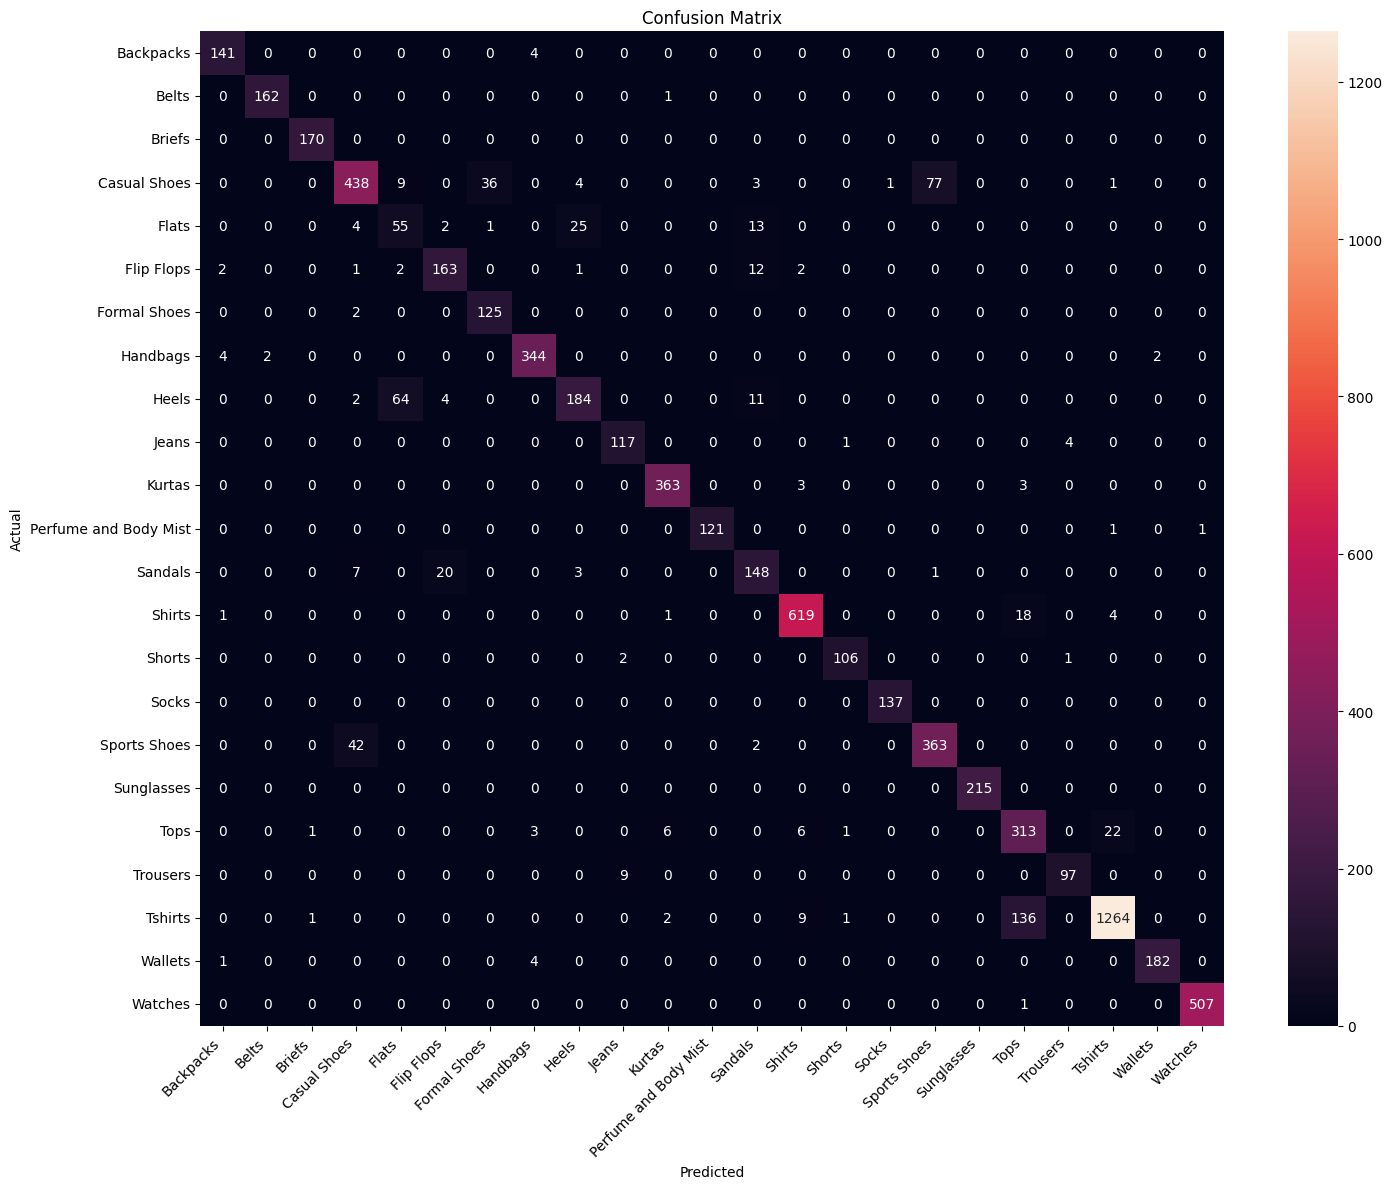

                       precision    recall  f1-score   support

            Backpacks       0.95      0.97      0.96       145
                Belts       0.99      0.99      0.99       163
               Briefs       0.99      1.00      0.99       170
         Casual Shoes       0.88      0.77      0.82       569
                Flats       0.42      0.55      0.48       100
           Flip Flops       0.86      0.89      0.88       183
         Formal Shoes       0.77      0.98      0.87       127
             Handbags       0.97      0.98      0.97       352
                Heels       0.85      0.69      0.76       265
                Jeans       0.91      0.96      0.94       122
               Kurtas       0.97      0.98      0.98       369
Perfume and Body Mist       1.00      0.98      0.99       123
              Sandals       0.78      0.83      0.80       179
               Shirts       0.97      0.96      0.97       643
               Shorts       0.97      0.97      0.97  

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# predictions
y_pred = model.predict(test_data)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_data.classes

# confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(15, 12))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=CLASS_NAMES.values(),
            yticklabels=CLASS_NAMES.values())
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(classification_report(y_true, y_pred_classes,
      target_names=list(CLASS_NAMES.values())))

In [13]:
from tensorflow.keras.models import load_model
model = load_model("best_model_phase2 (3).keras")

##  Predict on a new images



Saving images (1).jpg to images (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
 Top predictions:
  Shirts                    93.0%
  Tshirts                   5.9%
  Briefs                    0.4%


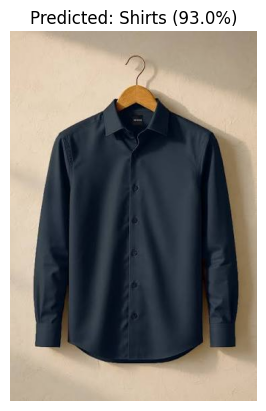

In [16]:
from PIL import Image
from tensorflow.keras.applications.efficientnet import preprocess_input

def predict_clothing(image_path):
    img = Image.open(image_path).convert('RGB')
    img = img.resize((224, 224))
    img_array = np.array(img).astype("float32")
    img_array = preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    preds = model.predict(img_array)[0]
    top3  = np.argsort(preds)[::-1][:3]

    print(" Top predictions:")
    for i in top3:
        print(f"  {CLASS_NAMES[i]:<25} {preds[i]*100:.1f}%")

    plt.imshow(np.array(Image.open(image_path)))
    plt.title(f"Predicted: {CLASS_NAMES[top3[0]]} ({preds[top3[0]]*100:.1f}%)")
    plt.axis('off')
    plt.show()

from google.colab import files
uploaded = files.upload()
fname = list(uploaded.keys())[0]
predict_clothing(fname)

Saving PLG_4264copy.webp to PLG_4264copy.webp
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
 Top predictions:
  Formal Shoes              99.5%
  Casual Shoes              0.5%
  Sports Shoes              0.0%


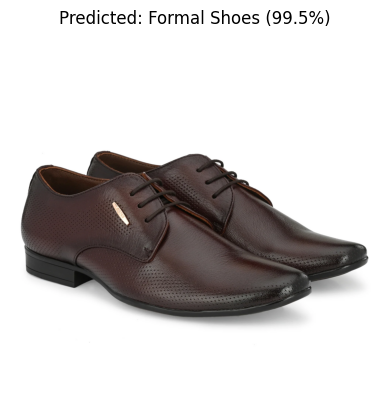

In [ ]:
from PIL import Image
from tensorflow.keras.applications.efficientnet import preprocess_input

def predict_clothing(image_path):
    img = Image.open(image_path).convert('RGB')
    img = img.resize((224, 224))
    img_array = np.array(img).astype("float32")
    img_array = preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    preds = model.predict(img_array)[0]
    top3  = np.argsort(preds)[::-1][:3]

    print(" Top predictions:")
    for i in top3:
        print(f"  {CLASS_NAMES[i]:<25} {preds[i]*100:.1f}%")

    plt.imshow(np.array(Image.open(image_path)))
    plt.title(f"Predicted: {CLASS_NAMES[top3[0]]} ({preds[top3[0]]*100:.1f}%)")
    plt.axis('off')
    plt.show()

from google.colab import files
uploaded = files.upload()
fname = list(uploaded.keys())[0]
predict_clothing(fname)

Saving Htcenly-Running-Shoes-Men-Fashion-Sneakers-Casual-Walking-Shoes-Sport-Athletic-Shoes-Lightweight-Breathable-Comfortable_4114141f-7d26-4dd7-933d-babc24080395.516ad145e1a1d8d82a801ac48231950d.avif to Htcenly-Running-Shoes-Men-Fashion-Sneakers-Casual-Walking-Shoes-Sport-Athletic-Shoes-Lightweight-Breathable-Comfortable_4114141f-7d26-4dd7-933d-babc24080395.516ad145e1a1d8d82a801ac48231950d.avif
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
 Top predictions:
  Sports Shoes              98.0%
  Casual Shoes              2.0%
  Formal Shoes              0.0%


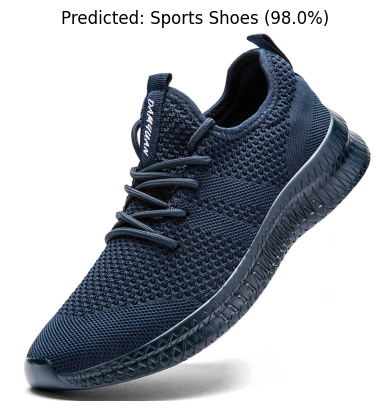

In [ ]:
from PIL import Image
from tensorflow.keras.applications.efficientnet import preprocess_input

def predict_clothing(image_path):
    img = Image.open(image_path).convert('RGB')
    img = img.resize((224, 224))
    img_array = np.array(img).astype("float32")
    img_array = preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    preds = model.predict(img_array)[0]
    top3  = np.argsort(preds)[::-1][:3]

    print(" Top predictions:")
    for i in top3:
        print(f"  {CLASS_NAMES[i]:<25} {preds[i]*100:.1f}%")

    plt.imshow(np.array(Image.open(image_path)))
    plt.title(f"Predicted: {CLASS_NAMES[top3[0]]} ({preds[top3[0]]*100:.1f}%)")
    plt.axis('off')
    plt.show()

from google.colab import files
uploaded = files.upload()
fname = list(uploaded.keys())[0]
predict_clothing(fname)

Saving CS2056_Male_OversizedOrganicT-Shirt-DeepBlack_2_2adc696d-0930-4a7f-86b1-61ad0c6dc3e9.webp to CS2056_Male_OversizedOrganicT-Shirt-DeepBlack_2_2adc696d-0930-4a7f-86b1-61ad0c6dc3e9.webp
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
 Top predictions:
  Tshirts                   99.0%
  Shirts                    1.0%
  Kurtas                    0.0%


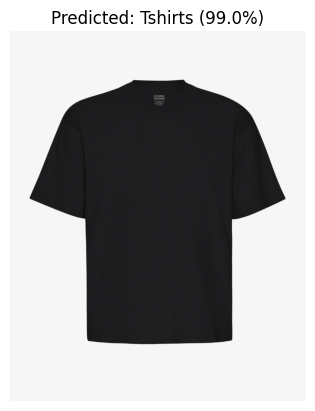

In [ ]:
from PIL import Image
from tensorflow.keras.applications.efficientnet import preprocess_input

def predict_clothing(image_path):
    img = Image.open(image_path).convert('RGB')
    img = img.resize((224, 224))
    img_array = np.array(img).astype("float32")
    img_array = preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    preds = model.predict(img_array)[0]
    top3  = np.argsort(preds)[::-1][:3]

    print(" Top predictions:")
    for i in top3:
        print(f"  {CLASS_NAMES[i]:<25} {preds[i]*100:.1f}%")

    plt.imshow(np.array(Image.open(image_path)))
    plt.title(f"Predicted: {CLASS_NAMES[top3[0]]} ({preds[top3[0]]*100:.1f}%)")
    plt.axis('off')
    plt.show()

from google.colab import files
uploaded = files.upload()
fname = list(uploaded.keys())[0]
predict_clothing(fname)